In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB

from pathlib import Path

In [56]:
RESULTS_DIR = Path('/data/equake_results/encoding_decoding_v3/')

SESSIONS_ALL = [
    'M061_2025_03_06_14_00',
    'M061_2025_03_05_14_00',
    'M063_2025_03_13_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',  # excluded: baseline std collapses → z-scores unreliable
    'M103_2026_02_18_15_30',
    'M106_2026_02_25_15_00',
]

EXCLUDE_AREAS = {
    'M062_2025_03_20_14_00': ['VAL'],
    'M062_2025_03_21_14_00': ['VAL'],
}

AREAS_PLOT = ['MOp', 'SSp', 'CP', 'VAL']

# Baseline window for normalization (seconds, relative to perturbation onset)
BASELINE_S = (-1.0, -0.2)

KP_ORDER_ALL = [
    'left_paw',   'left_wrist',   'left_elbow',   'left_shoulder',
    'right_paw',  'right_wrist',  'right_elbow',  'right_shoulder',
    'left_foot',  'left_ankle',   'left_knee',
    'right_foot', 'right_ankle',  'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]


In [57]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def load_session(sess, results_dir=RESULTS_DIR):
    """Load all area files for one session.
    Returns dict {area: data_dict} and the shared time axis (window centres, s).
    """
    files = sorted(results_dir.glob(f'moving_win_dec_*_{sess}_npcs*.pkl'))
    if not files:
        return {}, None
    sess_data = {}
    for f in files:
        # moving_win_dec_<AREA>_<SESSION>_npcs<N>.pkl
        area = f.name.split('_')[3]
        sess_data[area] = load_pkl(f)
        n_pcs = sess_data[area]['_meta']['n_pcs']
        kps = [k for k in sess_data[area] if k != '_meta']
        print(f'  {area:5s} | {n_pcs:3d} PCs | {len(kps)} keypoints')
    _first = next(iter(sess_data.values()))
    _first_kp = [k for k in _first if k != '_meta'][0]
    all_t = np.array(sorted(_first[_first_kp].keys()))
    return sess_data, all_t


def build_matrix(sess_data, area, kp_order, all_t, baseline_s=BASELINE_S):
    """Return (n_kp, n_t) raw ΔR² matrix (baseline mean subtracted, no std division)."""
    bl = (all_t >= baseline_s[0]) & (all_t < baseline_s[1])
    mat = []
    for kp in kp_order:
        if kp not in sess_data[area]:
            mat.append(np.full(len(all_t), np.nan))
            continue
        curve = np.array([sess_data[area][kp][t].mean() for t in all_t])
        mat.append(curve - curve[bl].mean())
    return np.array(mat)  # (n_kp, n_t)


def plot_session_heatmap(sess_data, all_t, sess, exclude_areas=None, shared_vlim=None):
    """2×2 heatmap figure for one session. Returns fig."""
    exclude_areas = exclude_areas or []
    avail = [a for a in AREAS_PLOT if a in sess_data and a not in exclude_areas]
    kp_order = [kp for kp in KP_ORDER_ALL
                if any(kp in sess_data.get(a, {}) for a in avail)]

    mats = {area: build_matrix(sess_data, area, kp_order, all_t) for area in avail}

    if shared_vlim is None:
        all_vals = np.concatenate([m[~np.isnan(m)] for m in mats.values()])
        vlim = np.percentile(np.abs(all_vals), 97)
    else:
        vlim = shared_vlim

    _meta0 = next(iter(sess_data.values()))['_meta']
    fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                             sharey=True, constrained_layout=True)

    for ax, area in zip(axes.flat, AREAS_PLOT):
        if area not in mats:
            ax.set_title(f'{area} (excluded / no data)')
            ax.set_visible(False)
            continue

        mat   = mats[area]
        n_pcs = sess_data[area]['_meta']['n_pcs']

        im = ax.imshow(
            mat, aspect='auto', cmap='RdBu_r',
            vmin=-vlim, vmax=vlim,
            extent=[all_t[0], all_t[-1], len(kp_order) - 0.5, -0.5],
        )
        ax.axvline(0, color='k', lw=1.2, ls='--')
        ax.set_xlabel('Time re. perturbation (s)')
        ax.set_title(f'{area}  ({n_pcs} PCs)', fontsize=11)
        ax.set_yticks(range(len(kp_order)))
        ax.set_yticklabels(kp_order, fontsize=8)
        cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
        cb.set_label('ΔR²  (baseline-subtracted)', fontsize=8)

    fig.suptitle(
        f'{sess}  —  ΔR²  (baseline subtracted)\n'
        f'window={_meta0["window_s"]} s  step={_meta0["step_s"]} s  vlim=±{vlim:.3f}',
        fontsize=11,
    )
    return fig, mats, kp_order


print('Helpers loaded.')


Helpers loaded.



M061_2025_03_06_14_00
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints


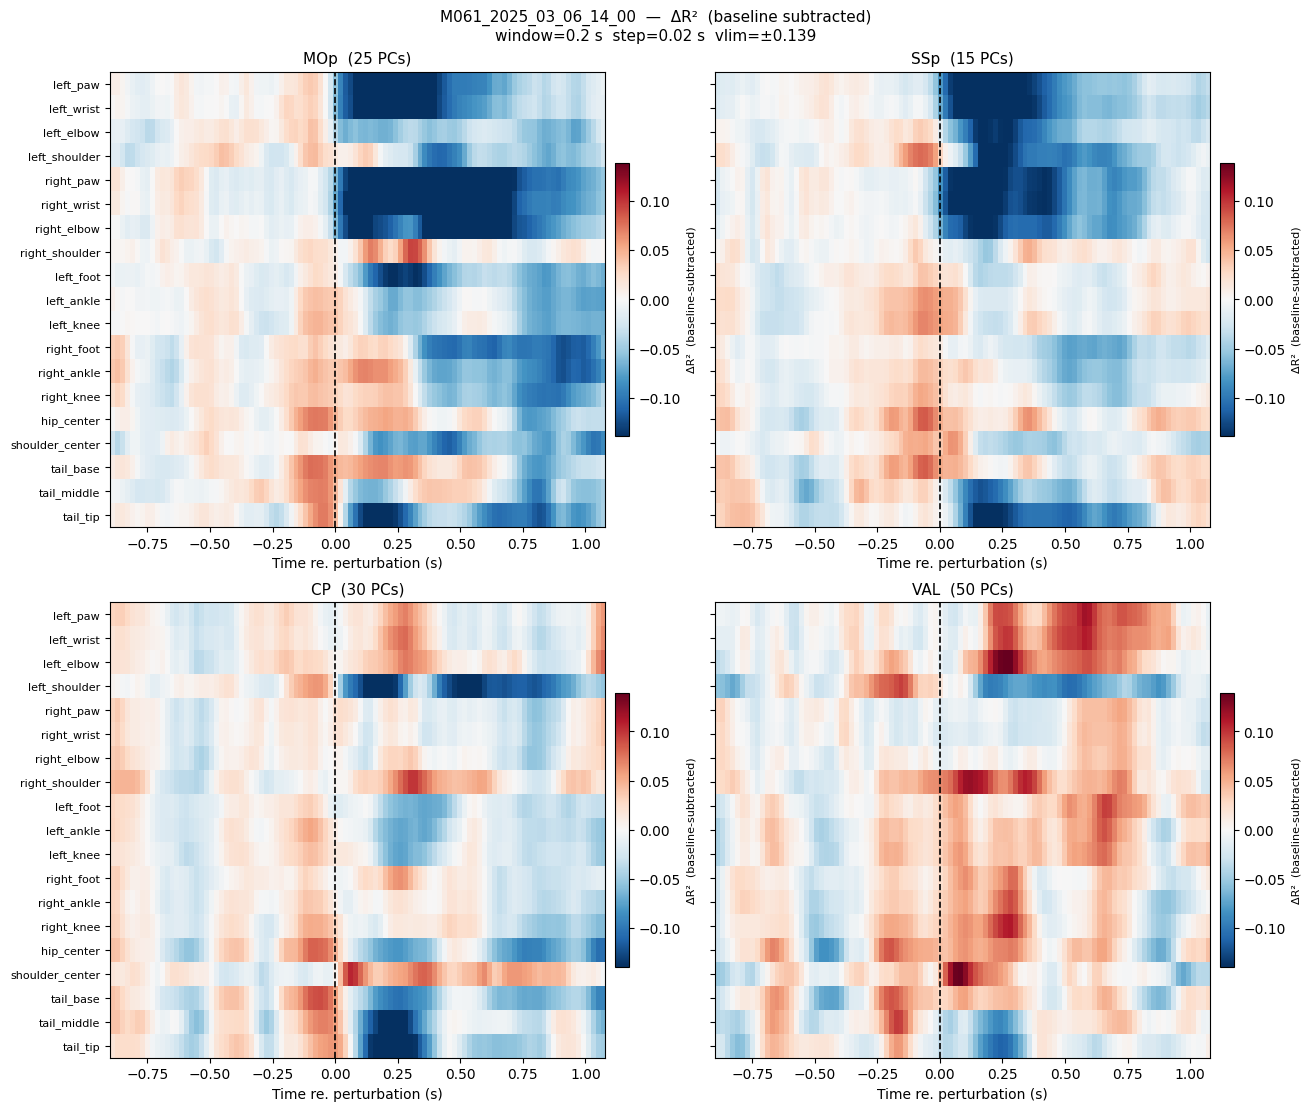


M061_2025_03_05_14_00
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints


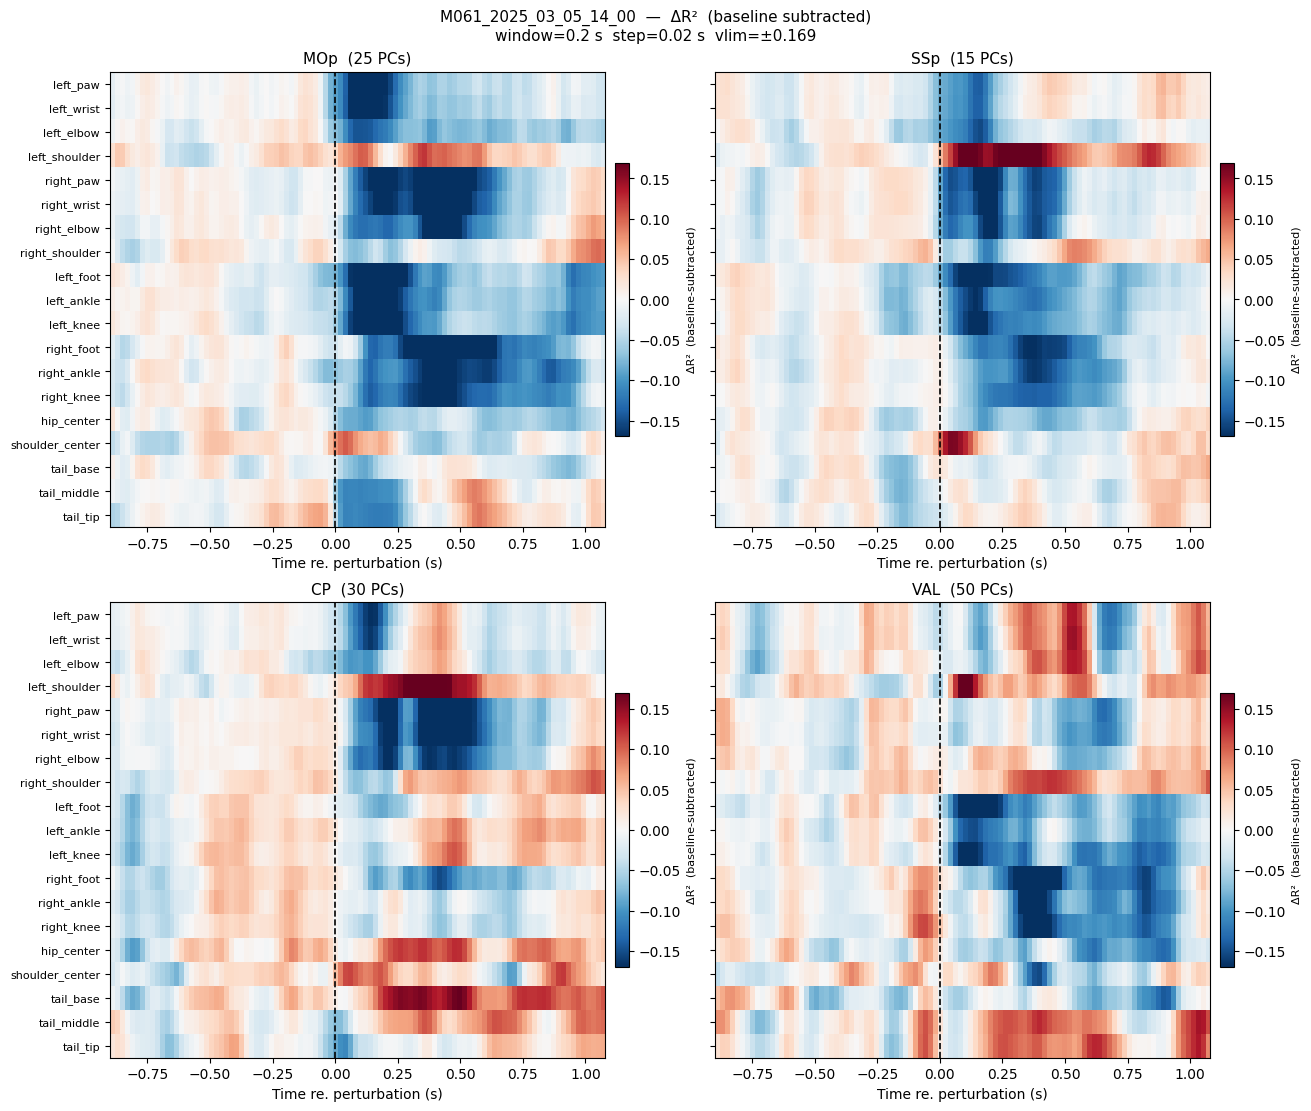


M063_2025_03_13_14_00
  No files found, skipping.

M062_2025_03_20_14_00
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints


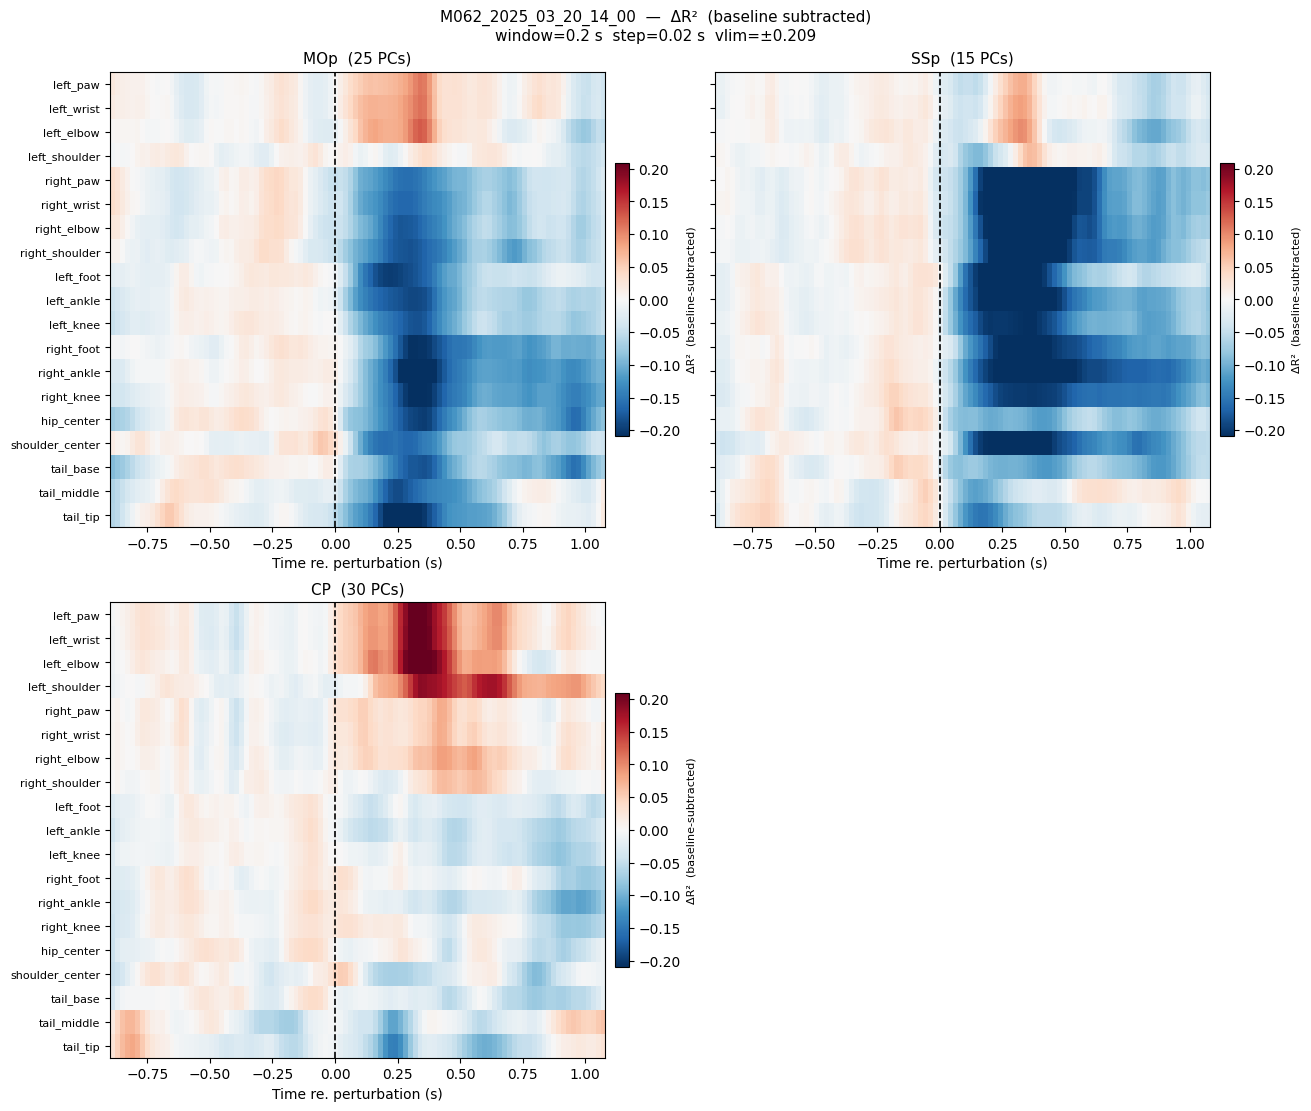


M062_2025_03_21_14_00
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints


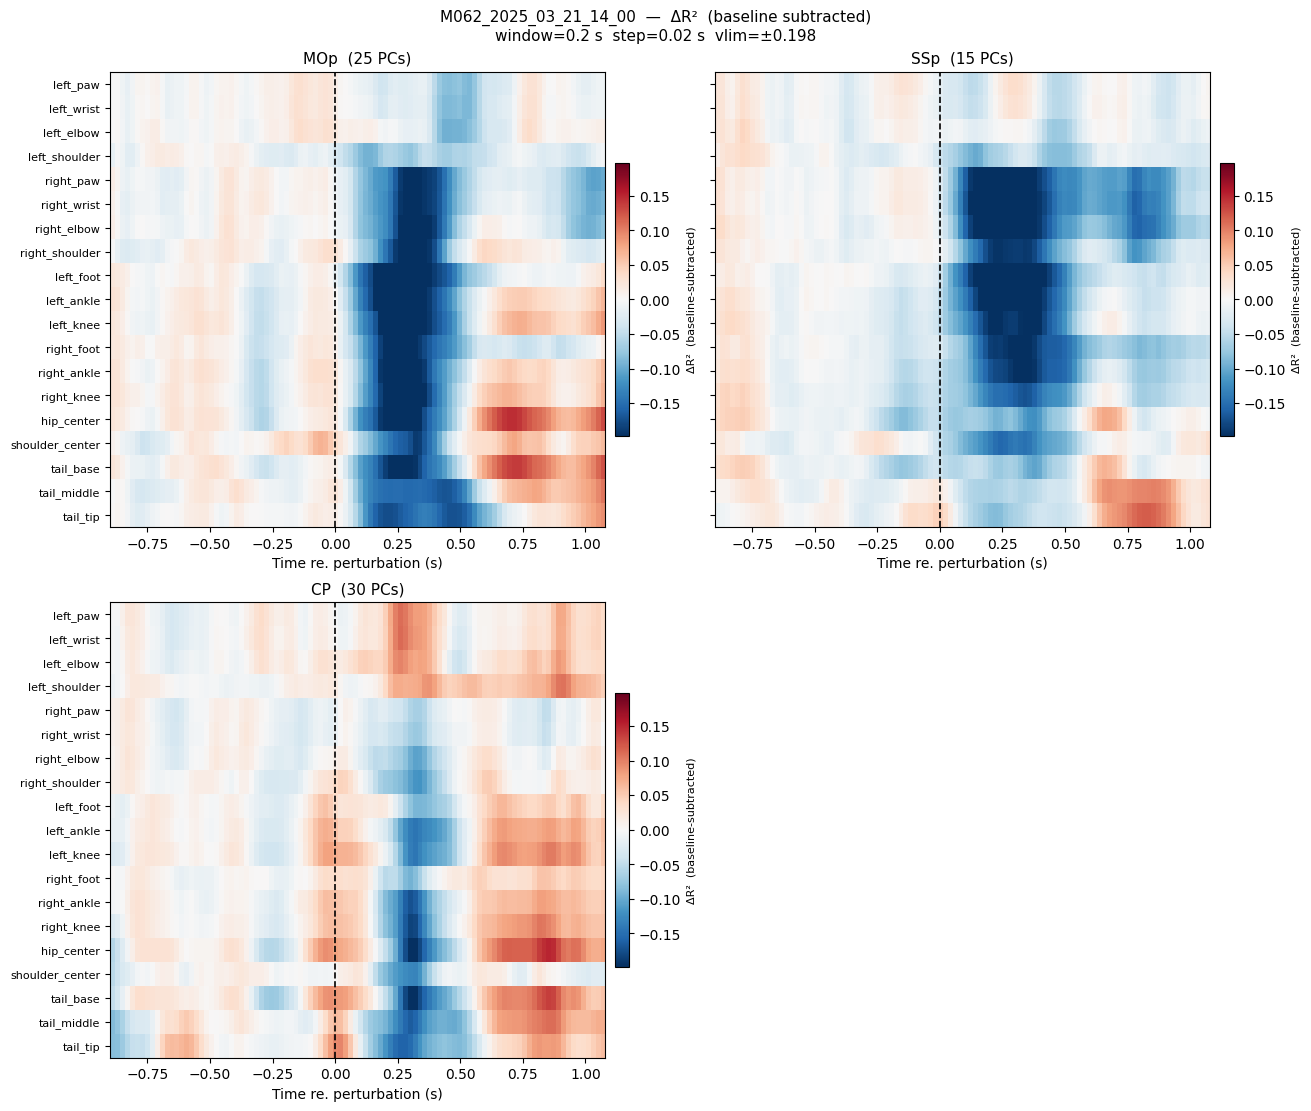


M078_2025_08_06_15_00
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints


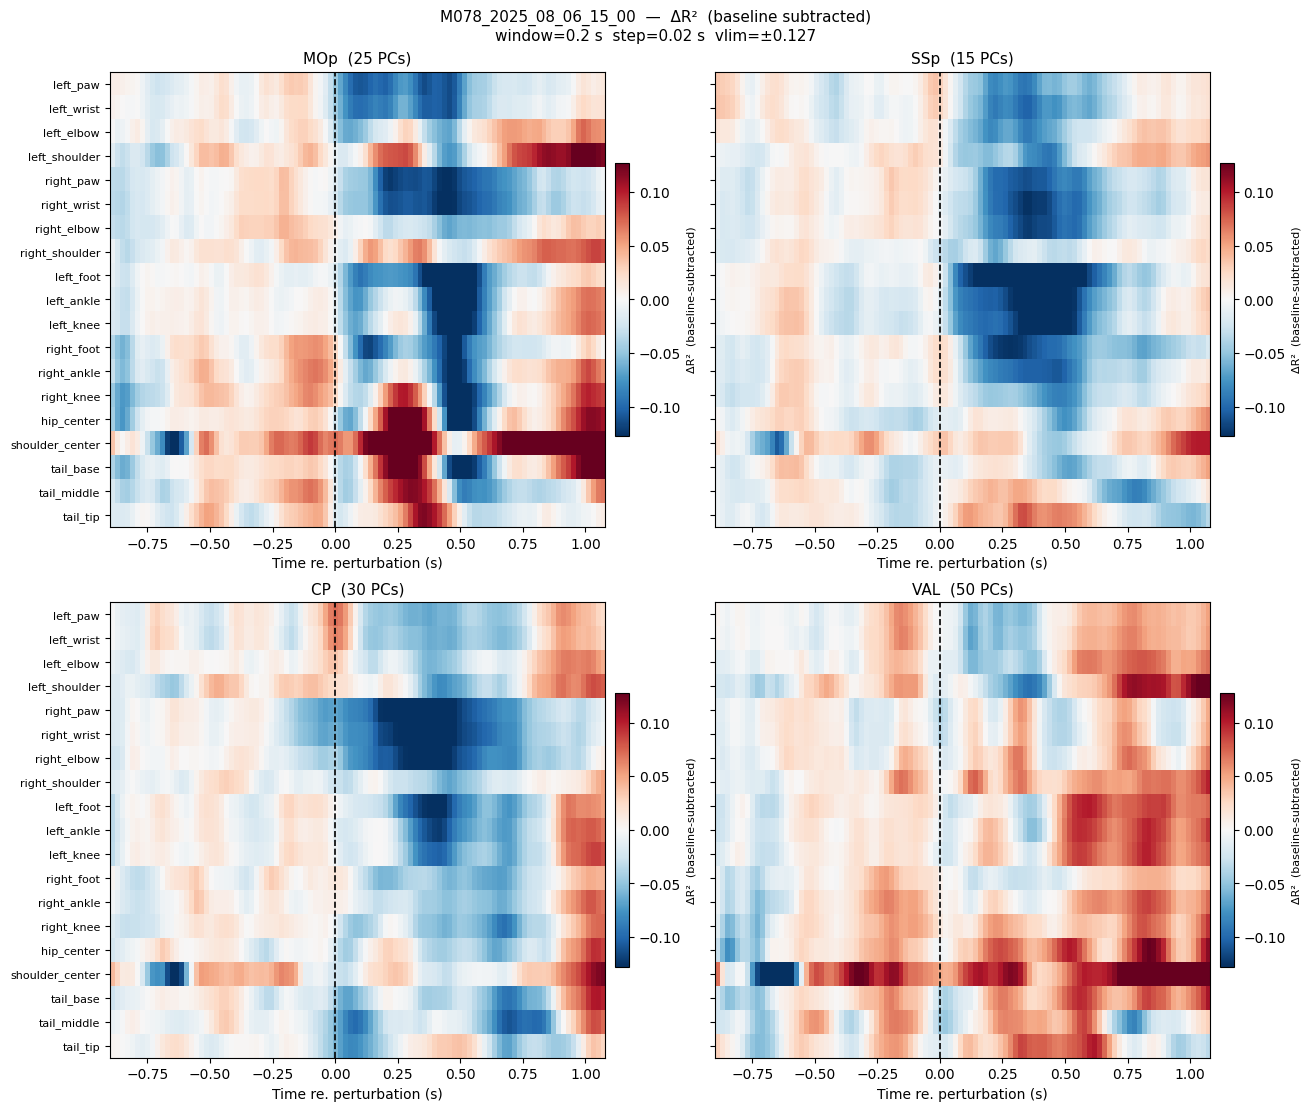


M103_2026_02_18_15_30
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints


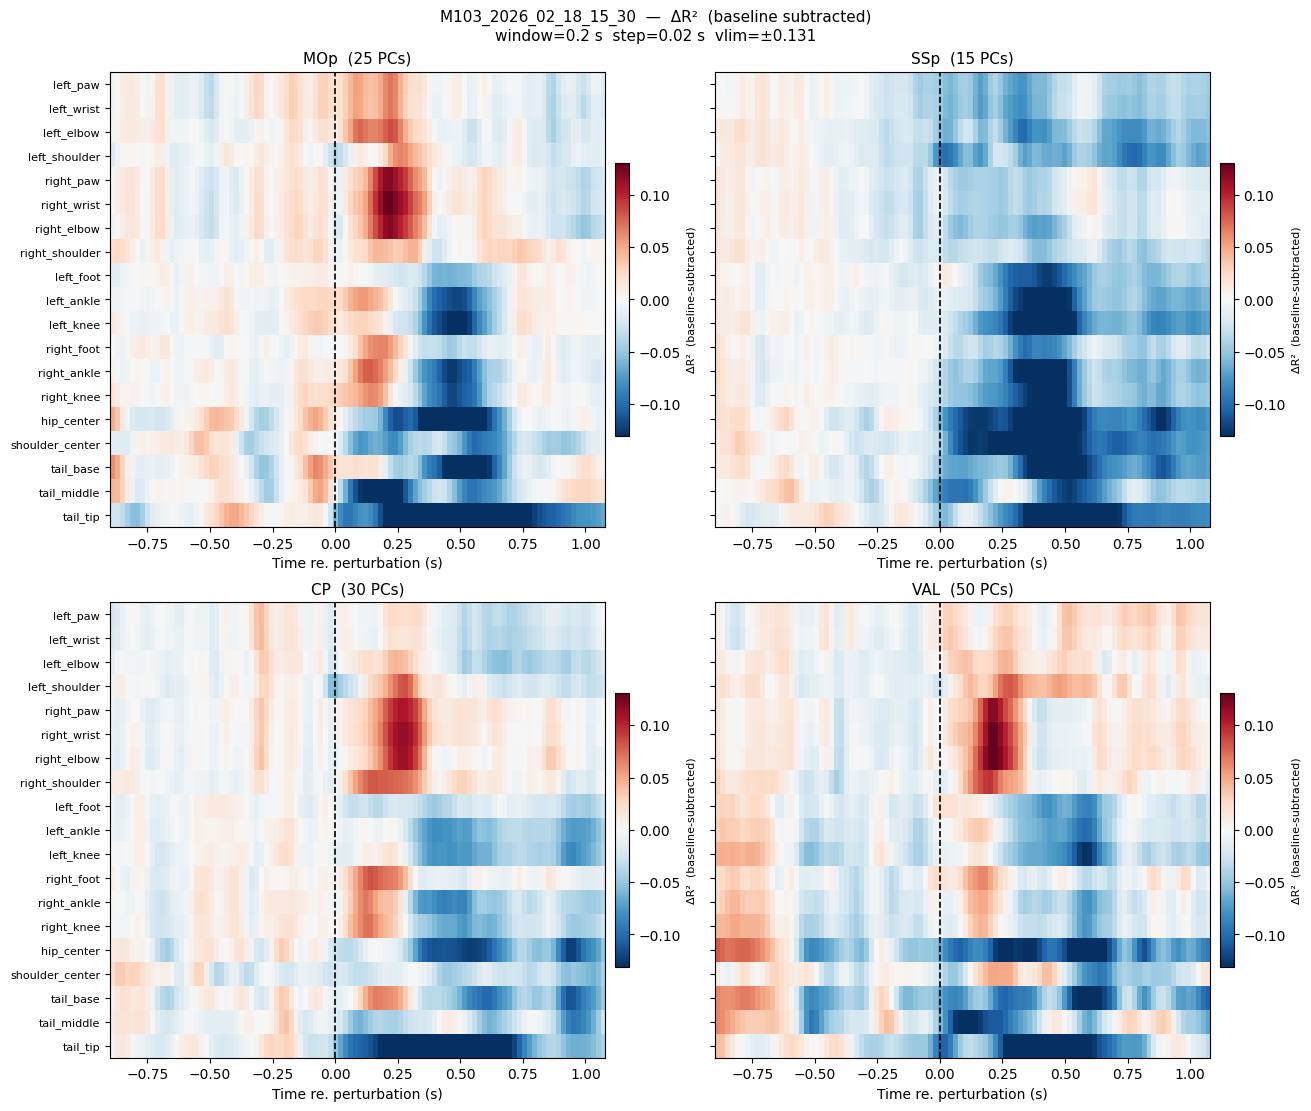


M106_2026_02_25_15_00
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints


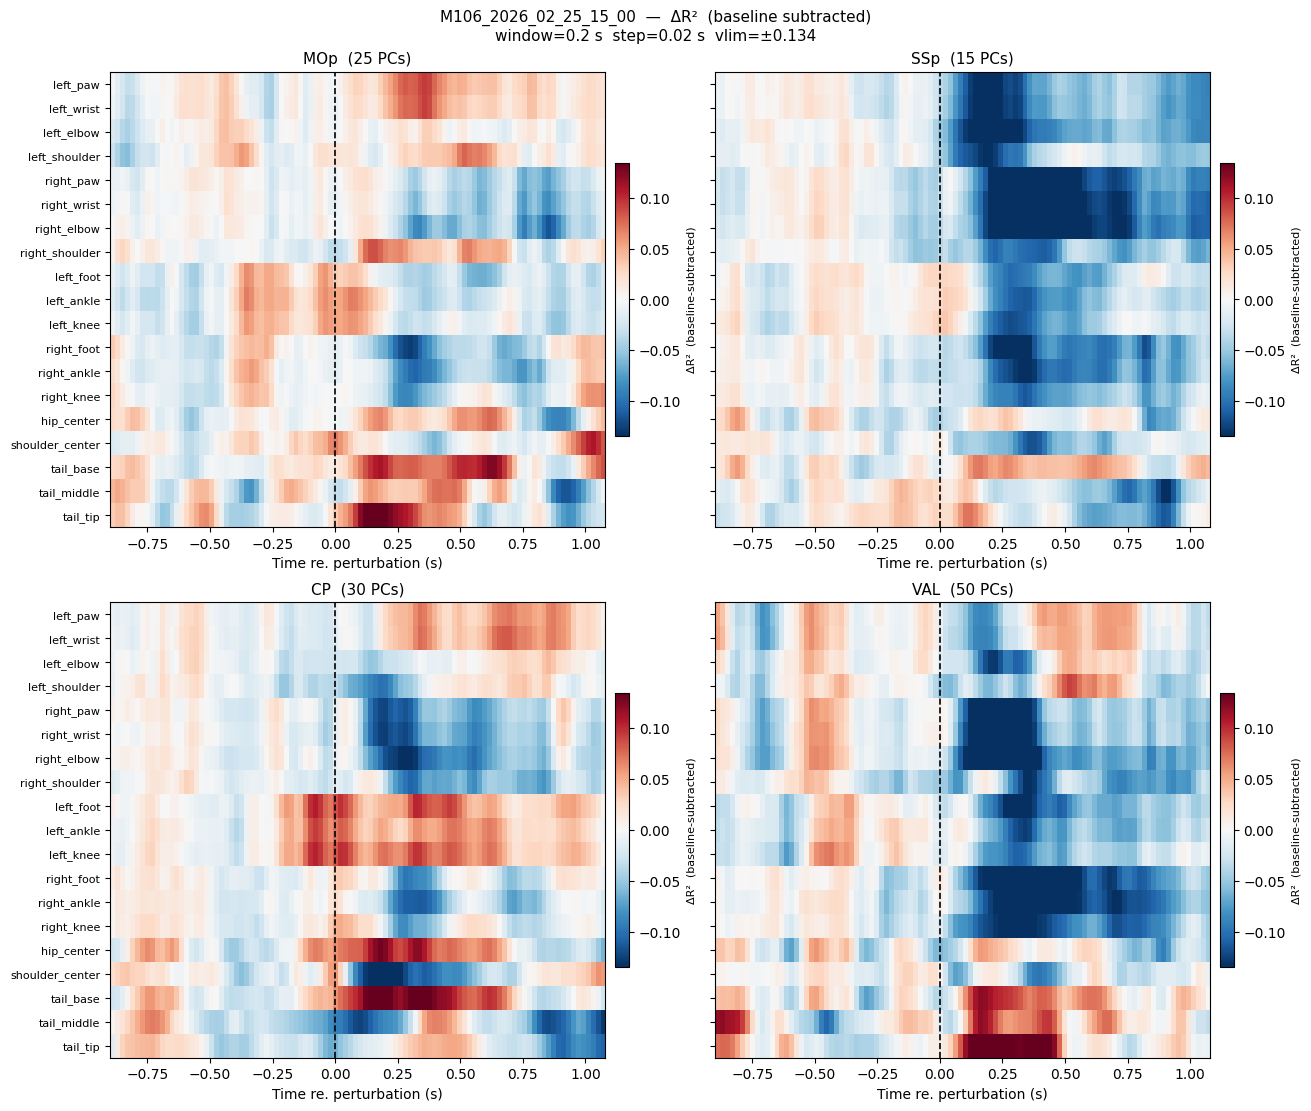

In [11]:
for sess in SESSIONS_ALL:
    print(f'\n{sess}')
    sess_data, all_t = load_session(sess)
    if not sess_data:
        print('  No files found, skipping.')
        continue
    fig, _, _ = plot_session_heatmap(
        sess_data, all_t, sess,
        exclude_areas=EXCLUDE_AREAS.get(sess, []),
    )
    plt.show()


## Grand mean across sessions

  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints
  M061_2025_03_06_14_00 | MOp | mat (19, 100)
  M061_2025_03_06_14_00 | SSp | mat (19, 100)
  M061_2025_03_06_14_00 | CP | mat (19, 100)
  M061_2025_03_06_14_00 | VAL | mat (19, 100)
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  VAL   |  50 PCs | 19 keypoints
  M061_2025_03_05_14_00 | MOp | mat (19, 100)
  M061_2025_03_05_14_00 | SSp | mat (19, 100)
  M061_2025_03_05_14_00 | CP | mat (19, 100)
  M061_2025_03_05_14_00 | VAL | mat (19, 100)
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  M062_2025_03_20_14_00 | MOp | mat (19, 100)
  M062_2025_03_20_14_00 | SSp | mat (19, 100)
  M062_2025_03_20_14_00 | CP | mat (19, 100)
  CP    |  30 PCs | 19 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  M062_2025_03_21_14_00 | MOp | mat

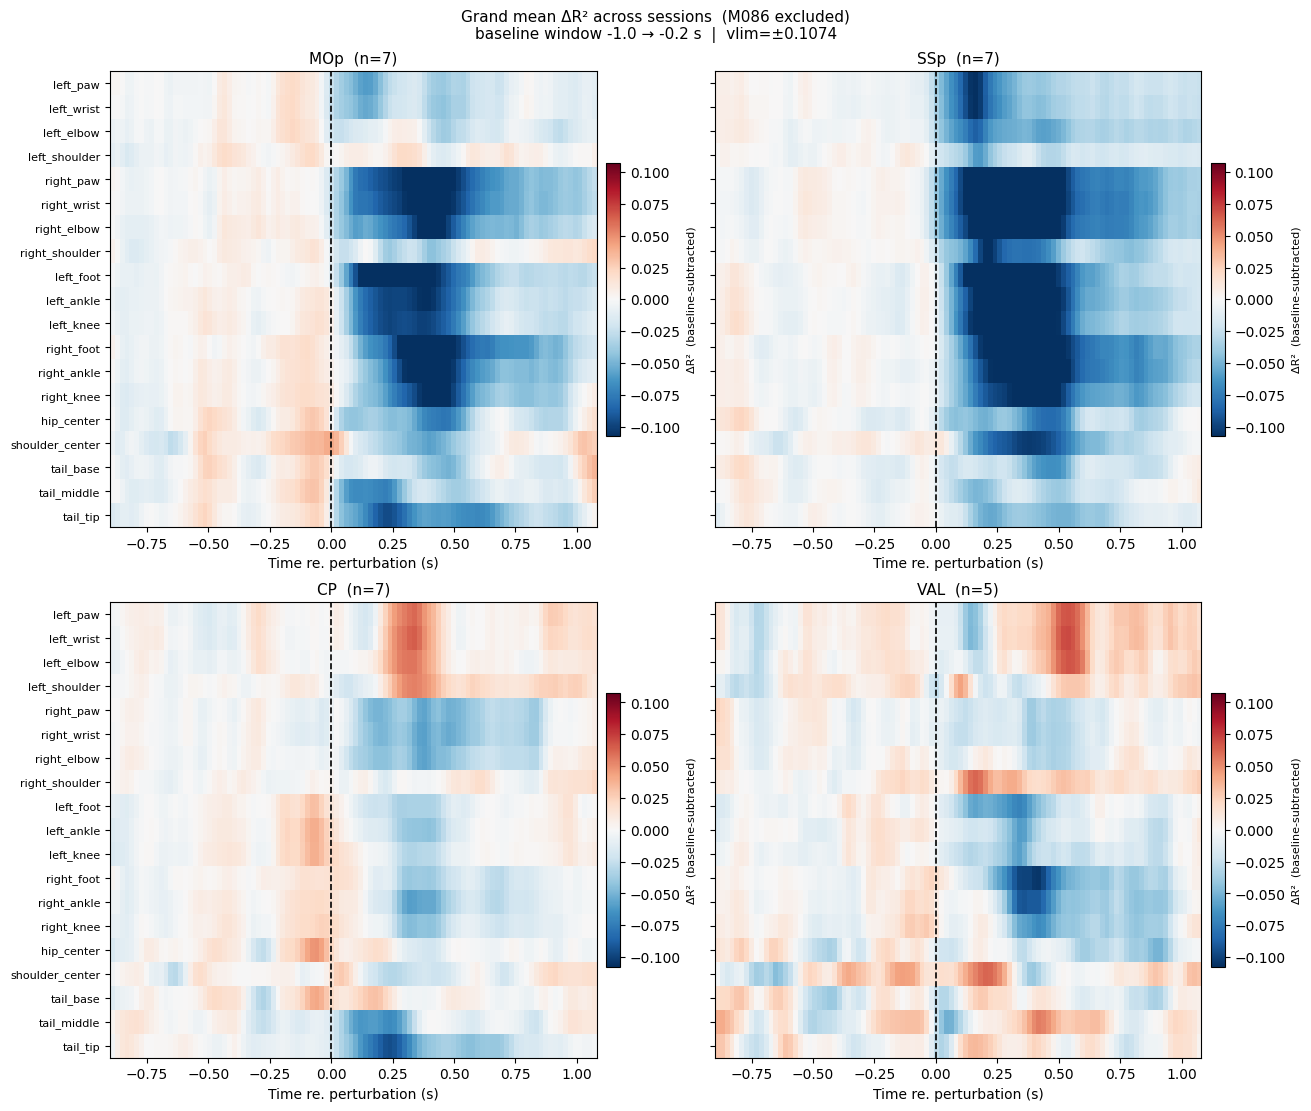

In [12]:
# Accumulate one ΔR² matrix per session per area
mats_per_area = {a: [] for a in AREAS_PLOT}
ref_t = None
kp_order_ref = None
n_sess_per_area = {a: 0 for a in AREAS_PLOT}

for sess in SESSIONS_ALL:
    sess_data, all_t = load_session(sess)
    if not sess_data:
        continue
    if ref_t is None:
        ref_t = all_t
    excl    = EXCLUDE_AREAS.get(sess, [])
    avail   = [a for a in AREAS_PLOT if a in sess_data and a not in excl]
    kp_order = [kp for kp in KP_ORDER_ALL
                if any(kp in sess_data.get(a, {}) for a in avail)]
    if kp_order_ref is None:
        kp_order_ref = kp_order

    for area in AREAS_PLOT:
        if area not in sess_data or area in excl:
            continue
        mat = build_matrix(sess_data, area, kp_order_ref, all_t)
        mats_per_area[area].append(mat)
        n_sess_per_area[area] += 1
        print(f'  {sess} | {area} | mat {mat.shape}')

# Grand mean + shared colour scale
grand_means = {}
all_grand   = []
for a in AREAS_PLOT:
    if mats_per_area[a]:
        gm = np.nanmean(mats_per_area[a], axis=0)
        grand_means[a] = gm
        all_grand.append(gm[~np.isnan(gm)])

vlim = np.percentile(np.abs(np.concatenate(all_grand)), 97)
print(f'\nShared vlim = ±{vlim:.4f}')
for a in AREAS_PLOT:
    print(f'  {a}: n={n_sess_per_area[a]} sessions')

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                         sharey=True, constrained_layout=True)

for ax, area in zip(axes.flat, AREAS_PLOT):
    if area not in grand_means:
        ax.set_title(f'{area} (no data)')
        ax.set_visible(False)
        continue

    gm = grand_means[area]
    n  = n_sess_per_area[area]

    im = ax.imshow(
        gm, aspect='auto', cmap='RdBu_r',
        vmin=-vlim, vmax=vlim,
        extent=[ref_t[0], ref_t[-1], len(kp_order_ref) - 0.5, -0.5],
    )
    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_title(f'{area}  (n={n})', fontsize=11)
    ax.set_yticks(range(len(kp_order_ref)))
    ax.set_yticklabels(kp_order_ref, fontsize=8)
    cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('ΔR²  (baseline-subtracted)', fontsize=8)

    post = gm[:, ref_t > 0]
    print(f'{area}: post mean={np.nanmean(post):.4f}  max|ΔR²|={np.nanmax(np.abs(gm)):.4f}')

fig.suptitle(
    f'Grand mean ΔR² across sessions  (M086 excluded)\n'
    f'baseline window {BASELINE_S[0]} → {BASELINE_S[1]} s  |  vlim=±{vlim:.4f}',
    fontsize=11,
)
plt.show()


---
## Bhv-PCA decoding  (`kin_dec_moving_win_bhv.py`)

One R² curve per area per session — neural PCs → top 15 bhv PCs (xyz + angles, all keypoints).

In [20]:
BHV_RESULTS_DIR = Path('/data/equake_results/encoding_decoding_v4/')


def load_bhv_session(sess, results_dir=BHV_RESULTS_DIR):
    """Load all area files for one bhv-PCA session.
    Returns dict {area: (all_t, mean_r2, fold_r2)} or empty dict.
    """
    files = sorted(results_dir.glob(f'moving_win_bhv_*_{sess}_npcs*.pkl'))
    if not files:
        return {}
    sess_data = {}
    for f in files:
        # moving_win_bhv_<AREA>_<SESSION>_npcs<N>_nbhv<K>.pkl
        area = f.name.split('_')[3]
        d    = load_pkl(f)
        scores_dict = d['scores']          # {t_centre: (n_folds,)}
        all_t   = np.array(sorted(scores_dict.keys()))
        fold_r2 = np.array([scores_dict[t] for t in all_t])  # (n_t, n_folds)
        sess_data[area] = {
            'all_t':   all_t,
            'fold_r2': fold_r2,           # (n_t, n_folds)
            'mean_r2': fold_r2.mean(-1),  # (n_t,)
            'meta':    d['_meta'],
        }
        print(f"  {area:5s} | neural {d['_meta']['n_neural_pcs']} PCs "
              f"→ {d['_meta']['n_bhv_pcs']} bhv PCs | {len(all_t)} windows")
    return sess_data


print('Bhv-PCA helpers loaded.')


Bhv-PCA helpers loaded.


In [22]:
colors

tools.params.colors


M061_2025_03_06_14_00
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  VAL   | neural 50 PCs → 15 bhv PCs | 100 windows
  MOp: post mean ΔR²=-0.1023
  SSp: post mean ΔR²=-0.0973
  CP: post mean ΔR²=-0.0181
  VAL: post mean ΔR²=-0.0020

M061_2025_03_05_14_00
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  VAL   | neural 50 PCs → 15 bhv PCs | 100 windows
  MOp: post mean ΔR²=-0.0917
  SSp: post mean ΔR²=-0.0545
  CP: post mean ΔR²=-0.0594
  VAL: post mean ΔR²=-0.0461

M063_2025_03_13_14_00

M062_2025_03_20_14_00
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  MOp: post mean ΔR²=-0.0727
  SSp: post mean ΔR²=-0.0934
  CP: post mean ΔR²=-0.0025

M062_2025_03_21_14_00
  CP    

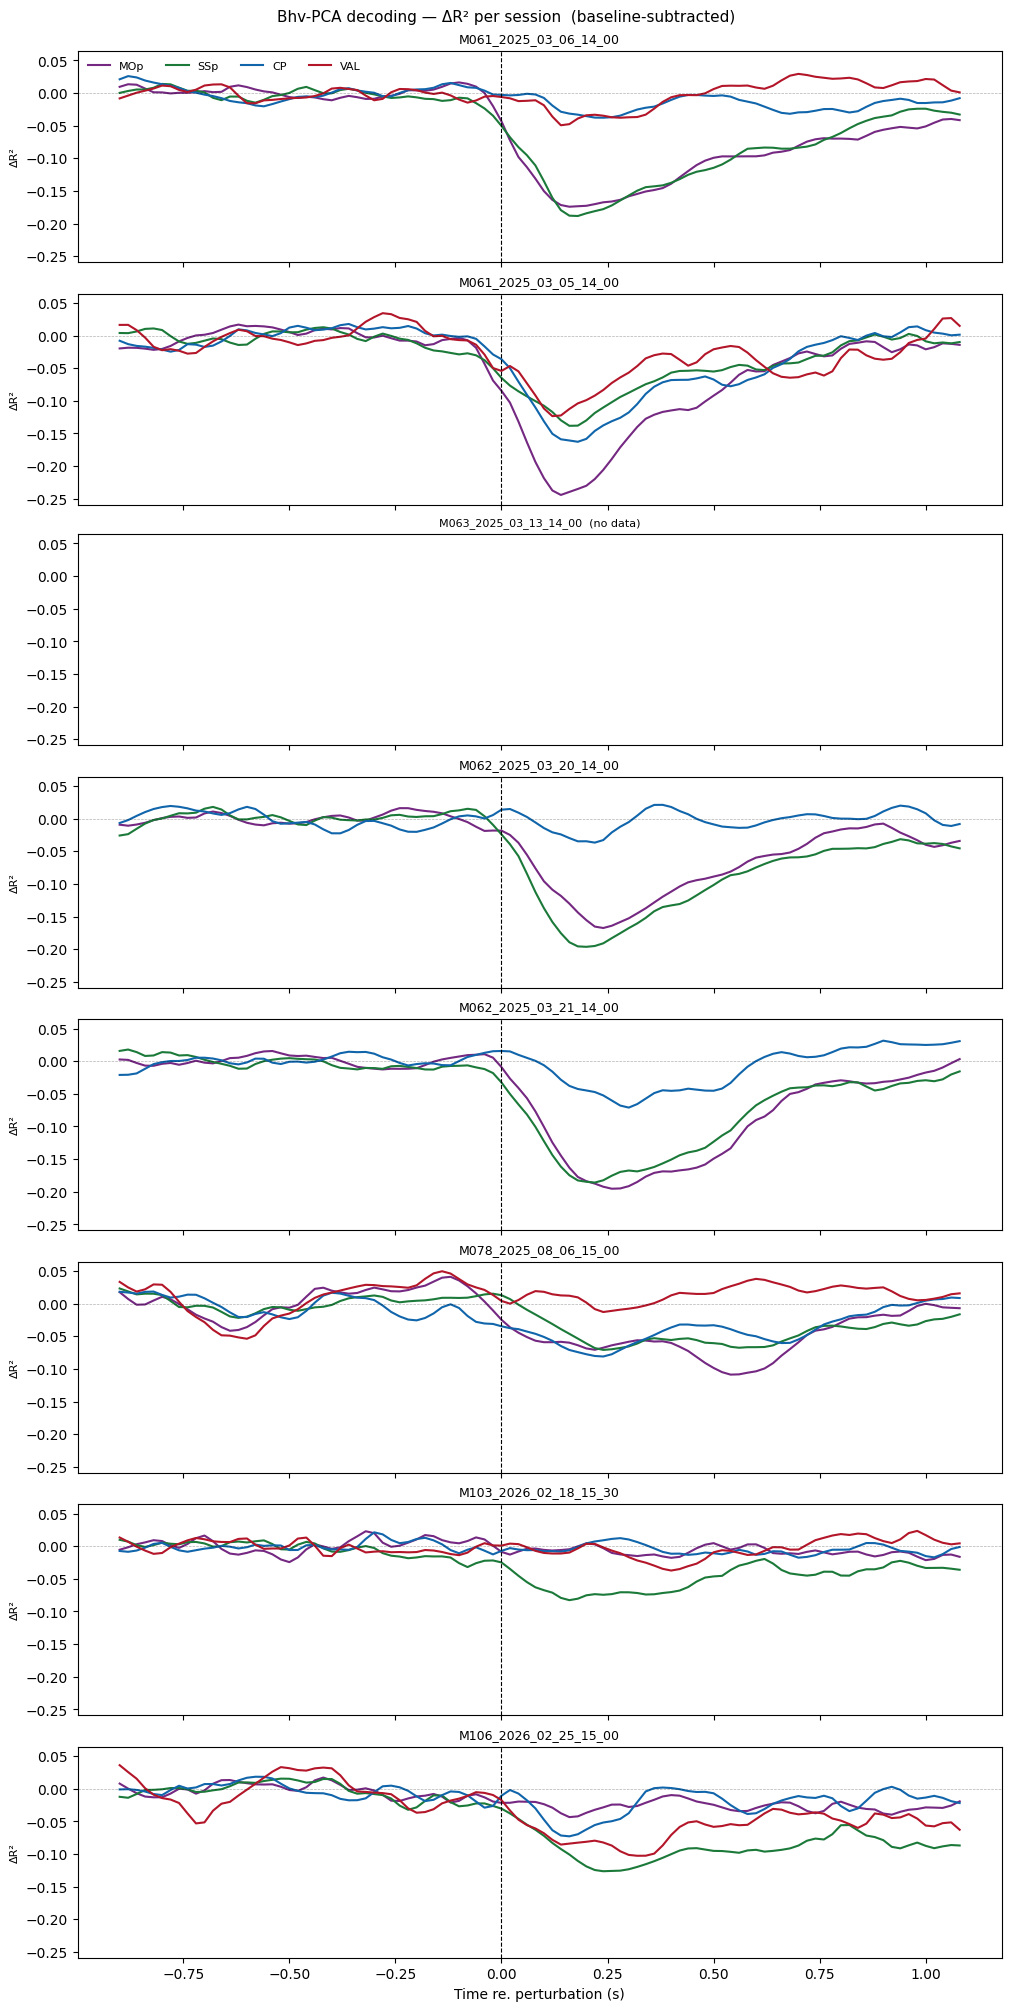

In [24]:
# ── Per-session: one subplot per session, areas overlaid ──────────────────────
n_sess_plot = len(SESSIONS_ALL)
fig, axes = plt.subplots(n_sess_plot, 1,
                         figsize=(10, 2.5 * n_sess_plot),
                         sharex=True, sharey=True,
                         constrained_layout=True)

for ax, sess in zip(axes, SESSIONS_ALL):
    print(f'\n{sess}')
    bhv_data = load_bhv_session(sess)
    if not bhv_data:
        ax.set_title(f'{sess}  (no data)', fontsize=8)
        continue

    excl = EXCLUDE_AREAS.get(sess, [])
    ref_t = next(iter(bhv_data.values()))['all_t']

    for area in AREAS_PLOT:
        if area not in bhv_data or area in excl:
            continue
        d     = bhv_data[area]
        curve = d['mean_r2']
        bl    = (d['all_t'] >= BASELINE_S[0]) & (d['all_t'] < BASELINE_S[1])
        delta = curve - curve[bl].mean()
        ax.plot(d['all_t'], delta, color=getattr(colors, area), lw=1.5, label=area)
        print(f"  {area}: post mean ΔR²={delta[d['all_t'] > 0].mean():.4f}")

    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.3)
    ax.set_ylabel('ΔR²', fontsize=8)
    ax.set_title(sess, fontsize=9)

axes[0].legend(fontsize=8, frameon=False, ncol=len(AREAS_PLOT))
axes[-1].set_xlabel('Time re. perturbation (s)')
fig.suptitle('Bhv-PCA decoding — ΔR² per session  (baseline-subtracted)', fontsize=11)
plt.show()


  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  VAL   | neural 50 PCs → 15 bhv PCs | 100 windows
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  VAL   | neural 50 PCs → 15 bhv PCs | 100 windows
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bhv PCs | 100 windows
  SSp   | neural 15 PCs → 15 bhv PCs | 100 windows
  VAL   | neural 50 PCs → 15 bhv PCs | 100 windows
  CP    | neural 30 PCs → 15 bhv PCs | 100 windows
  MOp   | neural 25 PCs → 15 bh

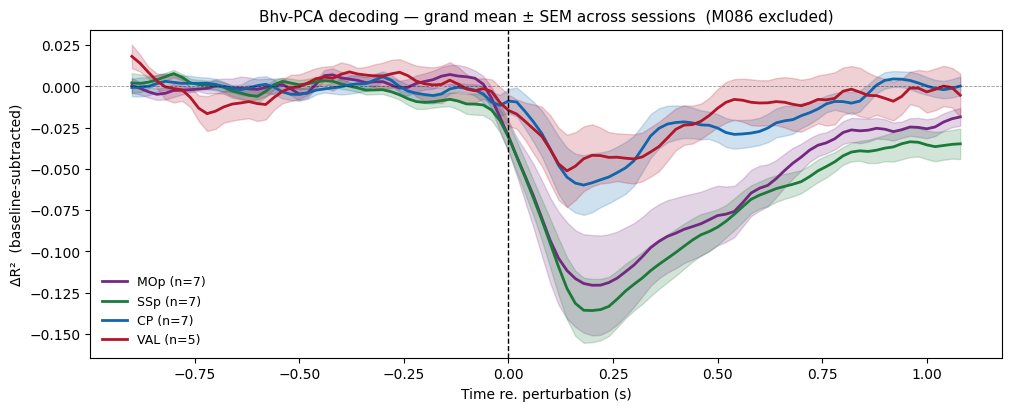

In [26]:
# ── Grand mean ± SEM across sessions, one line per area ───────────────────────
curves_per_area = {a: [] for a in AREAS_PLOT}
ref_t_bhv = None

for sess in SESSIONS_ALL:
    bhv_data = load_bhv_session(sess)
    if not bhv_data:
        continue
    excl = EXCLUDE_AREAS.get(sess, [])
    for area in AREAS_PLOT:
        if area not in bhv_data or area in excl:
            continue
        d  = bhv_data[area]
        bl = (d['all_t'] >= BASELINE_S[0]) & (d['all_t'] < BASELINE_S[1])
        delta = d['mean_r2'] - d['mean_r2'][bl].mean()
        curves_per_area[area].append(delta)
        if ref_t_bhv is None:
            ref_t_bhv = d['all_t']

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

for area in AREAS_PLOT:
    curves = curves_per_area[area]
    if not curves:
        continue
    arr  = np.array(curves)          # (n_sess, n_t)
    mean = arr.mean(0)
    sem  = arr.std(0) / np.sqrt(len(arr))
    col  = getattr(colors, area)
    ax.plot(ref_t_bhv, mean, color=col, lw=2, label=f'{area} (n={len(arr)})')
    ax.fill_between(ref_t_bhv, mean - sem, mean + sem, color=col, alpha=0.2)

    post = mean[ref_t_bhv > 0]
    print(f'{area}: n={len(arr)}  post mean ΔR²={post.mean():.4f}  peak={post.max():.4f}')

ax.axvline(0, color='k', lw=1, ls='--')
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel('Time re. perturbation (s)')
ax.set_ylabel('ΔR²  (baseline-subtracted)')
ax.legend(fontsize=9, frameon=False)
ax.set_title('Bhv-PCA decoding — grand mean ± SEM across sessions  (M086 excluded)', fontsize=11)
plt.show()


# Explore m062 sessions

In [23]:
SESSIONS_ALL = [
    'M061_2025_03_06_14_00',
    # 'M061_2025_03_05_14_00',
    # 'M063_2025_03_13_14_00',
    'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',  # excluded: baseline std collapses → z-scores unreliable
    # 'M103_2026_02_18_15_30',
    # 'M106_2026_02_25_15_00',
]

In [24]:
all_sess = dsp.load_sessions_for_trial_analyses(SESSIONS_ALL, std=0.03)

Loading sessions:   0%|          | 0/2 [00:00<?, ?it/s]


M061_2025_03_06_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 186  |  by value: 267  |  kept: 183/270 (67.8%)


Loading sessions:  50%|█████     | 1/2 [00:22<00:22, 22.77s/it]


M062_2025_03_20_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.85955056179775% of trials
  warnings.warn(


['SSp_spikes', 'VAL_spikes', 'all_spikes', 'CP_spikes', 'MOp_spikes']
Resulting SSp_spikes ephys data shape is (NxT): (118, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (155, 48000)
Resulting all_spikes ephys data shape is (NxT): (34, 48000)
Resulting CP_spikes ephys data shape is (NxT): (356, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (163, 48000)
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
Skipped 20 trials
Otsu immobility threshold: 3.9807
Dropped 27 of 354 rows (7.63%).
Thresh val dropping -2
  drop_trials_sem_crosses_zero: by SEM: 176  |  by value: 314  |  kept: 175/315 (55.6%)


Loading sessions: 100%|██████████| 2/2 [00:50<00:00, 25.39s/it]


Loaded 2/2 sessions successfully.


M061_2025_03_06_14_00 | left_elbow | 183 trials | 501 bins
  x: mean=-7.781  std=1.087
  y: mean=10.168  std=0.746
  z: mean=180.541  std=2.022


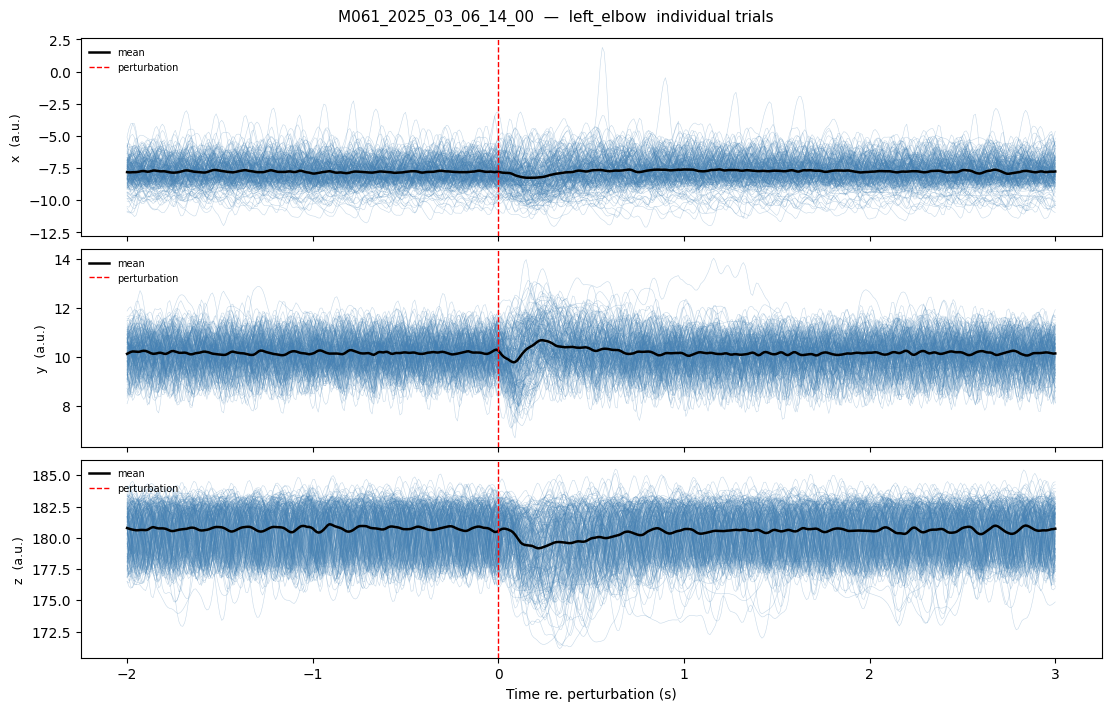

In [25]:
SESS = 'M062_2025_03_20_14_00'
SESS = 'M061_2025_03_06_14_00'
KP   = 'left_elbow'
DIMS = ['x', 'y', 'z']

td = all_sess[SESS]['td']

# time axis relative to perturbation onset (10 ms bins)
REL_START_S = -2.0
BIN_SIZE_S  = 0.01
n_bins = td[KP].iloc[0].shape[0]
t_axis = (np.arange(n_bins) + REL_START_S / BIN_SIZE_S) * BIN_SIZE_S

arr = np.stack(td[KP].values)  # (n_trials, n_time, 3)

print(f'{SESS} | {KP} | {arr.shape[0]} trials | {arr.shape[1]} bins')
for di, dim in enumerate(DIMS):
    print(f'  {dim}: mean={arr[:,:,di].mean():.3f}  std={arr[:,:,di].std():.3f}')

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, constrained_layout=True)

for di, (ax, dim) in enumerate(zip(axes, DIMS)):
    traces = arr[:, :, di]  # (n_trials, n_time)
    # individual trials
    for tr in traces:
        ax.plot(t_axis, tr, color='steelblue', lw=0.4, alpha=0.3)
    # mean
    ax.plot(t_axis, traces.mean(0), color='k', lw=1.8, label='mean')
    ax.axvline(0, color='r', lw=1, ls='--', label='perturbation')
    ax.set_ylabel(f'{dim}  (a.u.)', fontsize=9)
    ax.legend(fontsize=7, frameon=False, loc='upper left')

axes[-1].set_xlabel('Time re. perturbation (s)')
fig.suptitle(f'{SESS}  —  {KP}  individual trials', fontsize=11)
plt.show()


In [20]:
n_show

25

In [ ]:
N_TRIALS_SHOW = 25
DIM_COLORS = ['#e05c5c', '#5c9ee0', '#5cb85c']

n_show = min(N_TRIALS_SHOW, arr.shape[0])

for ti in np.arange(0, n_show):
    fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=True, constrained_layout=True)
    for di, (ax, dim, col) in enumerate(zip(axes, DIMS, DIM_COLORS)):
        ax.plot(t_axis, arr[ti, :, di], color=col, lw=1)
        ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylabel(dim, fontsize=9)
    axes[-1].set_xlabel('Time re. perturbation (s)')
    fig.suptitle(f'{KP}  —  trial {ti}', fontsize=10)
    plt.show()

print(f'Showed {n_show} trials')


(array([10., 24., 24., 18.,  9., 20., 12.,  7., 17., 20., 18.,  4.]),
 array([ 0.        ,  0.91666667,  1.83333333,  2.75      ,  3.66666667,
         4.58333333,  5.5       ,  6.41666667,  7.33333333,  8.25      ,
         9.16666667, 10.08333333, 11.        ]),
 <BarContainer object of 12 artists>)

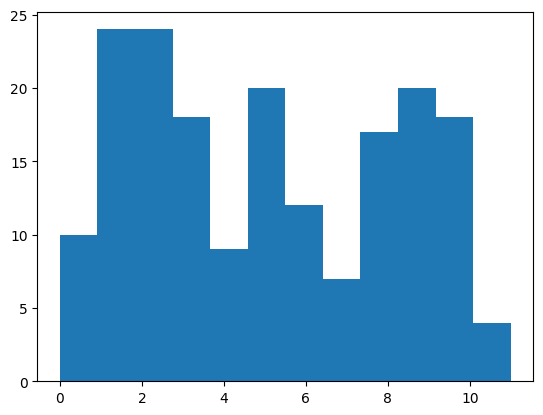

In [28]:
plt.hist(td.values_Sol_direction.values, bins=12)

# Pick trials that look similar

In [29]:
SESSIONS = [
    'M061_2025_03_06_14_00',
    # 'M061_2025_03_05_14_00',
    # 'M063_2025_03_13_14_00',
    # 'M062_2025_03_20_14_00',
    # 'M062_2025_03_21_14_00',
    # 'M078_2025_08_06_15_00',
    # 'M086_2025_12_10_15_00',  # excluded: baseline std collapses → z-scores unreliable
    # 'M103_2026_02_18_15_30',
    # 'M106_2026_02_25_15_00',
]

In [44]:
td, _ = dsp.load_and_process_session(SESSIONS[0], std=0.03)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
Skipped 40 trials
Otsu immobility threshold: 2.9536
Dropped 48 of 333 rows (14.41%).


## Option B: Cluster trials in kinematic PCA space

Cluster trials by their **pre-perturbation** kinematic trajectory (bins 0–200 = −2 to 0 s).  
The tightest cluster = most stereotyped locomotion → use as a clean decoder training/test set.

M061_2025_03_06_14_00 | 183 trials
Feature matrix: (183, 7200)
Variance explained by 10 PCs: 0.616
  PC1: 0.110
  PC2: 0.207
  PC3: 0.295
  PC4: 0.369
  PC5: 0.428
  PC6: 0.483
  PC7: 0.529
  PC8: 0.564
  PC9: 0.592
  PC10: 0.616


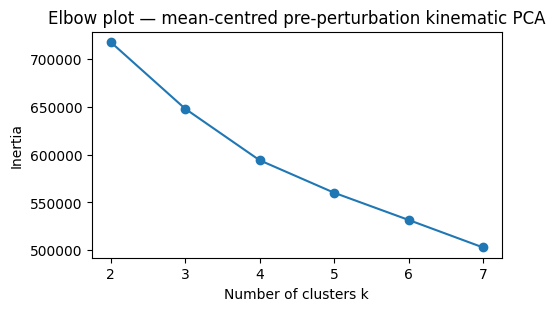

Inertias: ['717989.0', '648202.0', '594209.4', '560177.1', '531685.6', '502876.1']
Cluster 0: 50 trials
Cluster 1: 78 trials
Cluster 2: 55 trials


In [92]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

SESS       = 'M061_2025_03_06_14_00'
KPS        = Params.oscillating_key_points
PRE_BINS   = (0, 200)   # bins 0–200 → −2 to 0 s (rel_start=-200 in load_sessions)
N_KIN_PCS  = 10         # PCA dims before k-means
N_CLUSTERS = 3

td_cl = all_sess[SESS]['td'].copy()
n_trials = len(td_cl)
print(f'{SESS} | {n_trials} trials')

# ── Build feature matrix: mean-centred per trial to focus on oscillatory pattern ──
feats = []
for kp in KPS:
    arr = np.stack(td_cl[kp].values)              # (n_trials, n_bins, 3)
    pre = arr[:, PRE_BINS[0]:PRE_BINS[1], :]      # (n_trials, 200, 3)
    pre = pre - pre.mean(axis=1, keepdims=True)   # remove DC offset per trial
    feats.append(pre.reshape(n_trials, -1))
X = np.concatenate(feats, axis=1)                 # (n_trials, 200*3*12)
print(f'Feature matrix: {X.shape}')

# ── Standardise + PCA ──
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)
pca    = PCA(n_components=N_KIN_PCS, random_state=42)
X_pc   = pca.fit_transform(X_sc)
cumvar = pca.explained_variance_ratio_.cumsum()
print(f'Variance explained by {N_KIN_PCS} PCs: {cumvar[-1]:.3f}')
for i, v in enumerate(cumvar):
    print(f'  PC{i+1}: {v:.3f}')

# ── Elbow plot to help choose N_CLUSTERS ──
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_pc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
ax.plot(list(K_range), inertias, 'o-')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia')
ax.set_title('Elbow plot — mean-centred pre-perturbation kinematic PCA')
plt.show()
print('Inertias:', [f'{v:.1f}' for v in inertias])

# ── Fit chosen k ──
km     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
labels = km.fit_predict(X_pc)
for c in range(N_CLUSTERS):
    print(f'Cluster {c}: {(labels == c).sum()} trials')

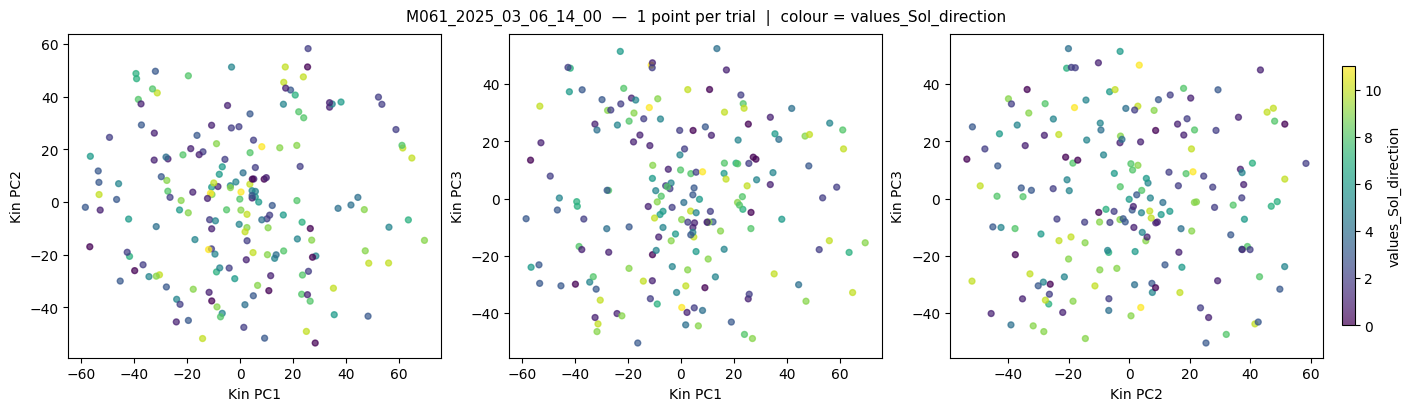

values_Sol_direction: min=0.000  median=5.000  max=11.000


In [95]:
# ── One point per trial in kinematic PC space ──────────────────────────────
# Colour options: 'disturb_mean', 'values_Sol_direction', 'sol_contra_ipsi'
COLOR_BY = 'values_Sol_direction'

color_vals = td_cl[COLOR_BY].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

pc_pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (xi, yi) in zip(axes, pc_pairs):
    sc = ax.scatter(X_pc[:, xi], X_pc[:, yi],
                    c=color_vals, cmap='viridis', s=18, alpha=0.7)
    ax.set_xlabel(f'Kin PC{xi+1}')
    ax.set_ylabel(f'Kin PC{yi+1}')

fig.colorbar(sc, ax=axes[-1], label=COLOR_BY, shrink=0.8)
fig.suptitle(f'{SESS}  —  1 point per trial  |  colour = {COLOR_BY}', fontsize=11)
plt.show()

print(f'{COLOR_BY}: min={color_vals.min():.3f}  median={np.median(color_vals):.3f}  max={color_vals.max():.3f}')

Cluster 0: left_knee-z  pre_std=3.777  disturb_mean=-0.540
Cluster 1: left_knee-z  pre_std=3.628  disturb_mean=-0.442
Cluster 2: left_knee-z  pre_std=3.997  disturb_mean=-0.518


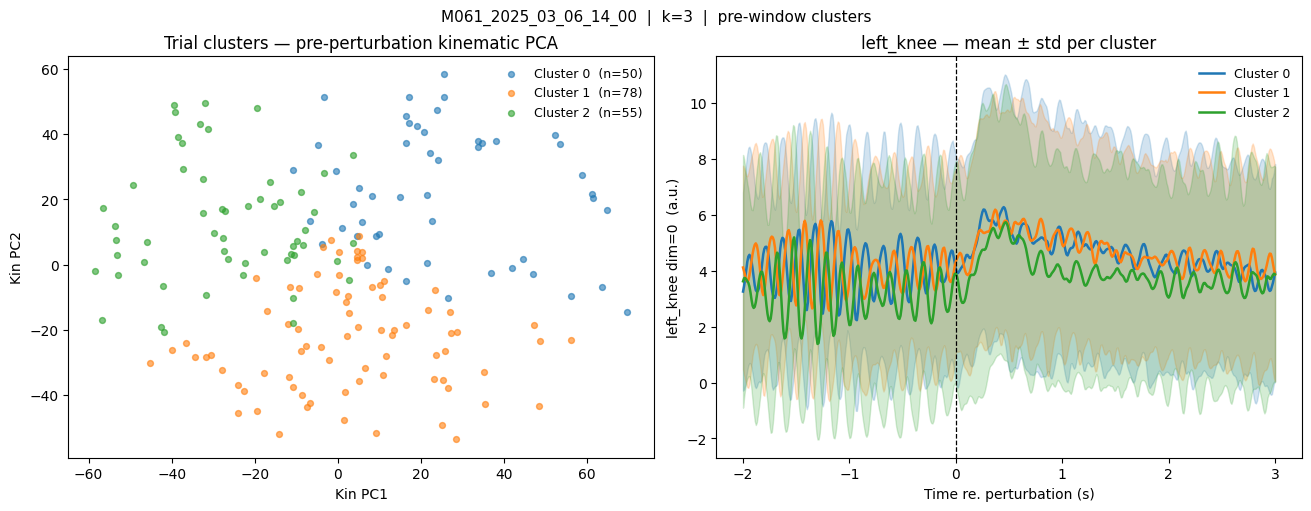

In [94]:
KP_SHOW   = 'left_knee'
DIM_SHOW  = 0   # z-axis tends to show gait clearly
CLUST_COLS = [f'C{i}' for i in range(N_CLUSTERS)]

arr_show = np.stack(td_cl[KP_SHOW].values)[:, :, DIM_SHOW]  # (n_trials, n_bins)
n_bins   = arr_show.shape[1]
t_axis   = (np.arange(n_bins) - PRE_BINS[1]) * 0.01          # seconds re. perturbation

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# ── Left: PC1 vs PC2, coloured by cluster ──
ax = axes[0]
for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(X_pc[mask, 0], X_pc[mask, 1], s=18, alpha=0.6,
               color=CLUST_COLS[c], label=f'Cluster {c}  (n={mask.sum()})')
ax.set_xlabel('Kin PC1')
ax.set_ylabel('Kin PC2')
ax.legend(fontsize=9, frameon=False)
ax.set_title('Trial clusters — pre-perturbation kinematic PCA')

# ── Right: mean ± std kinematic trace per cluster ──
ax = axes[1]
for c in range(N_CLUSTERS):
    mask = labels == c
    m = arr_show[mask].mean(0)
    s = arr_show[mask].std(0)
    ax.plot(t_axis, m, color=CLUST_COLS[c], lw=1.8, label=f'Cluster {c}')
    ax.fill_between(t_axis, m - s, m + s, color=CLUST_COLS[c], alpha=0.2)
    print(f'Cluster {c}: {KP_SHOW}-z  pre_std={arr_show[mask, :PRE_BINS[1]].std():.3f}'
          f'  disturb_mean={td_cl["disturb_mean"].values[mask].mean():.3f}')

ax.axvline(0, color='k', lw=0.9, ls='--')
ax.set_xlabel('Time re. perturbation (s)')
ax.set_ylabel(f'{KP_SHOW} dim={DIM_SHOW}  (a.u.)')
ax.legend(fontsize=9, frameon=False)
ax.set_title(f'{KP_SHOW} — mean ± std per cluster')

fig.suptitle(f'{SESS}  |  k={N_CLUSTERS}  |  pre-window clusters', fontsize=11)
plt.show()

In [87]:
# ── Select the tightest cluster (smallest mean distance to centroid) ──
centroid_dists = []
for c in range(N_CLUSTERS):
    mask = labels == c
    centroid = X_pc[mask].mean(0)
    dists = np.linalg.norm(X_pc[mask] - centroid, axis=1)
    centroid_dists.append(dists.mean())
    print(f'Cluster {c}: n={mask.sum()}  mean_dist_to_centroid={dists.mean():.3f}  '
          f'disturb_mean={td_cl["disturb_mean"].values[mask].mean():.3f} ± {td_cl["disturb_mean"].values[mask].std():.3f}')

tightest_cluster = int(np.argmin(centroid_dists))
print(f'\nTightest cluster: {tightest_cluster}  (mean dist={centroid_dists[tightest_cluster]:.3f})')

td_tight = td_cl[labels == tightest_cluster].copy().reset_index(drop=True)
print(f'td_tight: {len(td_tight)} / {len(td_cl)} trials retained')

Cluster 0: n=50  mean_dist_to_centroid=59.054  disturb_mean=-0.540 ± 0.376
Cluster 1: n=78  mean_dist_to_centroid=60.109  disturb_mean=-0.442 ± 0.336
Cluster 2: n=55  mean_dist_to_centroid=57.026  disturb_mean=-0.518 ± 0.364

Tightest cluster: 2  (mean dist=57.026)
td_tight: 55 / 183 trials retained


## Moving-window decoding on `td_tight` — per-trial demeaned kinematics

Same pipeline as `kin_dec_moving_window.py` but:
- Uses only the tightest kinematic cluster (`td_tight`)
- Each trial's kinematics are **demeaned** using the pre-perturbation baseline before decoding

In [40]:
KP_ORDER_ALL = [
    'left_paw',   'left_wrist',   'left_elbow',   'left_shoulder',
    'right_paw',  'right_wrist',  'right_elbow',  'right_shoulder',
    'left_foot',  'left_ankle',   'left_knee',
    'right_foot', 'right_ankle',  'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]

In [66]:
td_dropped = dsp.drop_trials_sem_crosses_zero(td, std=False)
perturb_td = pyal.restrict_to_interval(td_dropped, rel_start=-200, rel_end=300, start_point_name='idx_sol_on')

  drop_trials_sem_crosses_zero: by SEM: 218  |  by value: 267  |  kept: 215/270 (79.6%)


In [78]:
# ── Filter by perturbation direction ───────────────────────────────────────
DIRECTIONS = [2, 3, 4]   # ← set to None to keep all directions

if DIRECTIONS is not None:
    perturb_td_dir = perturb_td[perturb_td['values_Sol_direction'].isin(DIRECTIONS)].reset_index(drop=True)
    print(f'Kept directions {DIRECTIONS}: {len(perturb_td_dir)} trials')
else:
    perturb_td_dir = perturb_td.copy()
    print(f'All directions kept: {len(perturb_td_dir)} trials')

print(perturb_td_dir['values_Sol_direction'].value_counts().sort_index())

Kept directions [2, 3, 4]: 60 trials
values_Sol_direction
2    26
3    19
4    15
Name: count, dtype: int64


In [90]:
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import make_scorer, r2_score
from sklearn.model_selection import KFold, cross_validate

# ── Parameters (mirror kin_dec_moving_window.py defaults) ──────────────────
WINDOW_S    = 0.3
STEP_S      = 0.02
TIME_MIN    = -1.0
TIME_MAX    =  1.0
BIN_SIZE    = 0.01
PERTURB_BIN = 200          # abs index of perturbation onset (rel_start = -200)
N_JOBS      = -1           # use all cores

pc_dict       = {'MOp': 25, 'CP': 30, 'SSp': 15, 'VAL': 50}
AREAS_DEC     = ['MOp', 'SSp', 'CP', 'VAL']
KEYPOINTS_DEC = KP_ORDER_ALL

_window_bins = int(round(WINDOW_S / BIN_SIZE))
TIME_BINS_S  = np.arange(TIME_MIN, TIME_MAX, STEP_S)
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + PERTURB_BIN).astype(int)

vw_r2 = make_scorer(r2_score, multioutput='variance_weighted')

def _decode_kp(kp, neural_arr, td_dec):
    """Decode one keypoint — runs in a worker process."""
    if kp not in td_dec.columns:
        return kp, None

    kin_arr  = np.stack(td_dec[kp].values)                              # (n_trials, n_bins, 3)
    baseline = kin_arr[:, :PERTURB_BIN, :].mean(axis=1, keepdims=True)  # per-trial demean
    kin_arr  = kin_arr - baseline

    # Fit alpha once on all data, then score each window
    X_all = neural_arr.reshape(-1, neural_arr.shape[-1])
    y_all = kin_arr.reshape(-1, kin_arr.shape[-1])
    alpha = RidgeCV(alphas=np.logspace(-4, 3, 100)).fit(X_all, y_all).alpha_
    model = Ridge(alpha=alpha)
    cv    = KFold(n_splits=5, shuffle=False)

    results_kp = {}
    for t_s, t in zip(TIME_BINS_S, _time_bins):
        X = neural_arr[:, t:t + _window_bins, :].reshape(-1, neural_arr.shape[-1])
        y = kin_arr   [:, t:t + _window_bins, :].reshape(-1, kin_arr.shape[-1])
        scores = cross_validate(model, X, y, cv=cv, scoring=vw_r2, n_jobs=1)['test_score']
        results_kp[t_s + WINDOW_S / 2] = scores

    return kp, results_kp

# ── Shuffle trial order ─────────────────────────────────────────────────────
td_dec = td_tight.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Decoding on {len(td_dec)} trials')

# ── Main loop ───────────────────────────────────────────────────────────────
results_tight = {}

for area in AREAS_DEC[:1]:
    pca_col = f'{area}_rates_pca'
    if pca_col not in td_dec.columns:
        print(f'Skipping {area} — {pca_col} not found')
        continue

    n_pcs      = min(pc_dict[area], td_dec[pca_col].iloc[0].shape[-1])
    neural_arr = np.stack(td_dec[pca_col].values)[:, :, :n_pcs]
    print(f'{area} | {n_pcs} PCs | {len(td_dec)} trials | {len(KEYPOINTS_DEC)} keypoints')

    kp_results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(_decode_kp)(kp, neural_arr, td_dec) for kp in KEYPOINTS_DEC
    )

    results_tight[area] = {
        '_meta': {'n_pcs': n_pcs, 'window_s': WINDOW_S, 'step_s': STEP_S,
                  'area': area, 'session': SESS},
        **{kp: res for kp, res in kp_results if res is not None},
    }

print('\nDone.')

Decoding on 55 trials
MOp | 25 PCs | 55 trials | 19 keypoints


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  19 | elapsed:    4.8s remaining:   18.2s
[Parallel(n_jobs=-1)]: Done   8 out of  19 | elapsed:    8.5s remaining:   11.7s
[Parallel(n_jobs=-1)]: Done  12 out of  19 | elapsed:   12.1s remaining:    7.0s
[Parallel(n_jobs=-1)]: Done  16 out of  19 | elapsed:   15.7s remaining:    2.9s



Done.


[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed:   17.9s finished


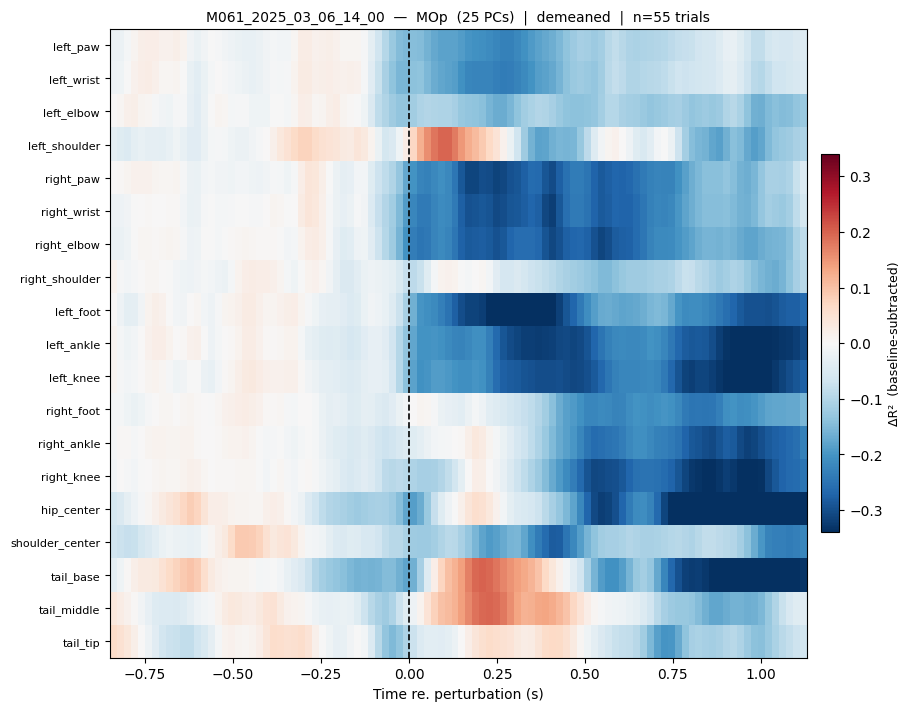

MOp: post mean ΔR²=-0.1636  peak|ΔR²|=0.6143


In [91]:
area_plot = 'MOp'

all_t_dec = np.array(sorted(
    next(v for k, v in results_tight[area_plot].items() if k != '_meta').keys()
))

mat        = build_matrix(results_tight, area_plot, KP_ORDER_ALL, all_t_dec)
n_pcs_plot = results_tight[area_plot]['_meta']['n_pcs']
vlim       = np.nanpercentile(np.abs(mat), 97)

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
im = ax.imshow(
    mat, aspect='auto', cmap='RdBu_r',
    vmin=-vlim, vmax=vlim,
    extent=[all_t_dec[0], all_t_dec[-1], len(KP_ORDER_ALL) - 0.5, -0.5],
)
ax.axvline(0, color='k', lw=1.2, ls='--')
ax.set_yticks(range(len(KP_ORDER_ALL)))
ax.set_yticklabels(KP_ORDER_ALL, fontsize=8)
ax.set_xlabel('Time re. perturbation (s)')
cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cb.set_label('ΔR²  (baseline-subtracted)', fontsize=9)
ax.set_title(
    f'{SESS}  —  {area_plot}  ({n_pcs_plot} PCs)  |  demeaned  |  n={len(td_dec)} trials',
    fontsize=10,
)
plt.show()

post_mask = all_t_dec > 0
print(f'{area_plot}: post mean ΔR²={np.nanmean(mat[:, post_mask]):.4f}  peak|ΔR²|={np.nanmax(np.abs(mat)):.4f}')

In [ ]:
all_t_tight = np.array(sorted(next(
    v for k, v in next(iter(results_tight.values())).items() if k != '_meta'
).keys()))

fig, _, _ = plot_session_heatmap(
    results_tight, all_t_tight,
    f'{SESS} — demeaned, tightest cluster (n={len(td_tight)})',
)
plt.show()

# Print summary stats
for area, res in results_tight.items():
    kps = [k for k in res if k != '_meta']
    mat = build_matrix(res, area, KP_ORDER_ALL, all_t_tight)
    post = mat[:, all_t_tight > 0]
    print(f'{area}: post mean ΔR²={np.nanmean(post):.4f}  peak|ΔR²|={np.nanmax(np.abs(mat)):.4f}')